2-2. 归一化


In [1]:
import scanpy as sc
import rapids_singlecell as rsc
import cupy as cp
import numpy as np  # 修改说明: ensure NumPy available before dtype cast
import scipy.sparse as sp  # 修改说明: ensure SciPy sparse available before CSR conversion


/home/zhen/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# adata = sc.read(
#     filename="s4d8_quality_control.h5ad",
#     backup_url="https://figshare.com/ndownloader/files/40014331",
# )
adata = sc.read_10x_h5("/home/zhen/GZ_Projects_2026/04_SC_Analysis/scanpy_path/filtered_feature_bc_matrix.h5")

/home/zhen/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



我们首先检查原始计数UMI的分布，一般在后续的分析中我们会忽略这一步，但对该分布的认识有利于我们理解归一化的意义。

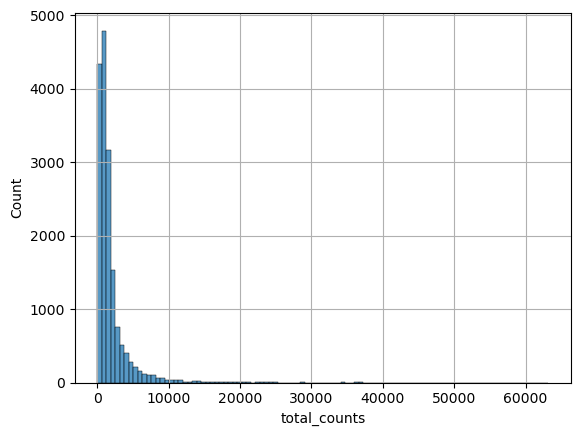

In [3]:
import seaborn as sns
# 修改说明: 若 total_counts 不存在则先计算 QC 指标，避免 KeyError
if "total_counts" not in adata.obs:
    sc.pp.calculate_qc_metrics(adata, inplace=True)
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)
# 修改说明: grid=True 用于显示网格线，便于读数
p1.grid(True)

/home/zhen/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Starting GPU-accelerated Pearson Residuals...


/home/zhen/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/zhen/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
... storing 'feature_types' as categorical
... storing 'genome' as categorical


Analysis complete on GPU!


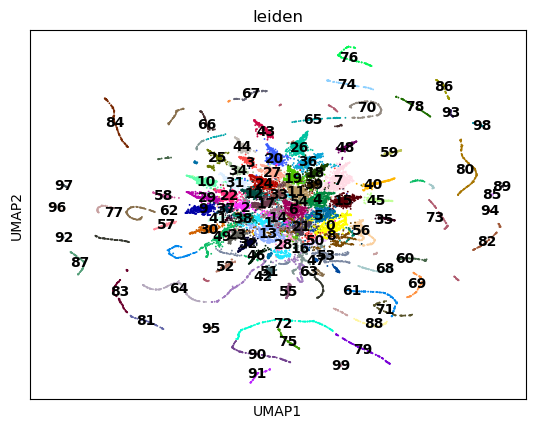

In [5]:
import numpy as np  # 修改说明: CPU normalization uses NumPy
import scipy.sparse as sp  # 修改说明: CPU normalization uses SciPy sparse
import scanpy as sc
import rapids_singlecell as rsc
import cupy as cp
import gc  # 修改说明: enable explicit GC for CPU memory

# 1. 读取数据（如果你是从 CPU 版本的 adata 开始）
# adata = sc.read("h5/dli_census.h5ad") 
adata = sc.read_10x_h5("/home/zhen/GZ_Projects_2026/04_SC_Analysis/scanpy_path/filtered_feature_bc_matrix.h5")

# 2. 【核心步骤】将数据从内存移动到 GPU 显存
# 这会将 adata.X 转换为 cupy 数组
rsc.get.anndata_to_GPU(adata)

# 3. 使用 GPU 版本的 Pearson Residuals 归一化
# 这一步在 CPU 上最容易导致崩溃，但在 GPU 上非常快且省内存
print("Starting GPU-accelerated Pearson Residuals...")
cp.get_default_memory_pool().free_all_blocks()  # 修改说明: clear CuPy memory pool before normalization
# 2.1 归一化前先做基因过滤与细胞下采样（降低内存压力）
X_gpu = adata.X
if hasattr(X_gpu, "get"):
    adata.X = X_gpu.get()  # 修改说明: move X to CPU before filter_genes
    del X_gpu  # 修改说明: drop GPU reference before CPU filtering
    cp.get_default_memory_pool().free_all_blocks()  # 修改说明: free GPU pool before filtering
import numpy as np  # 修改说明: in-place import for dtype cast below
import scipy.sparse as sp  # 修改说明: in-place import for CSR conversion below
sc.pp.filter_genes(adata, min_cells=50)  # 修改说明: increase min_cells to reduce genes
adata.X = adata.X.astype(np.float32)  # 修改说明: reduce X precision to save memory
if not sp.issparse(adata.X):
    adata.X = sp.csr_matrix(adata.X)  # 修改说明: convert dense X to CSR to save memory
if adata.n_obs > 50000:
    sc.pp.subsample(adata, n_obs=10000, random_state=0)  # 修改说明: downsample cells for quick analysis
# 3. 使用 CPU 版本的 Pearson Residuals 归一化（避免显存不足）

X_gpu = adata.X
if hasattr(X_gpu, "get"):
    adata.X = X_gpu.get()  # 修改说明: move X to CPU to avoid GPU OOM
    del X_gpu  # 修改说明: drop GPU reference before CPU normalization
    cp.get_default_memory_pool().free_all_blocks()  # 修改说明: free GPU pool after moving to CPU
sc.experimental.pp.normalize_pearson_residuals(
    adata,
    inplace=True,
)
gc.collect()  # 修改说明: clean CPU memory after normalization
# 3.1 修复潜在的 var/X 长度不一致
if adata.X.shape[1] != adata.var.shape[0]:
    adata = adata[:, adata.var_names].copy()  # 修改说明: align X with var to avoid length mismatch

# 4. 高变基因筛选 (CPU 版本，避免显存不足)
import numpy as np  # 修改说明: CPU HVG uses NumPy
import scipy.sparse as sp  # 修改说明: CPU HVG uses SciPy sparse
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat",  # 修改说明: scanpy CPU HVG only supports seurat/cell_ranger
    n_top_genes=100,  # 修改说明: lower HVG count to reduce memory
)
gc.collect()  # 修改说明: clean CPU memory after HVG
# 5. 后续常规分析（也全部使用 GPU 加速版本）
# 5. 后续常规分析（GPU 前先保留 HVG 子集）
if "highly_variable" in adata.var:
    adata = adata[:, adata.var["highly_variable"]].copy()  # 修改说明: subset to HVG before GPU steps
    cp.get_default_memory_pool().free_all_blocks()  # 修改说明: clear CuPy memory pool after subsetting
    rsc.get.anndata_to_GPU(adata)  # 修改说明: move HVG subset back to GPU
rsc.tl.pca(adata)
rsc.pp.neighbors(adata)
rsc.tl.umap(adata)
rsc.tl.leiden(adata)

print("Analysis complete on GPU!")

sc.pl.umap(adata, color=["leiden"], legend_loc="on data")  # 修改说明: louvain not computed, plot leiden only


In [ ]:
import numpy as np  # 修改说明: CPU normalization uses NumPy
import scipy.sparse as sp  # 修改说明: CPU normalization uses SciPy sparse
import scanpy as sc
import rapids_singlecell as rsc
import cupy as cp
import gc  # 修改说明: enable explicit GC for CPU memory



/home/zhen/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'adata' is not defined

<div style="color:yellow">
皮尔森近似残差在WSL永远死机，Windows似乎可以成功
</div>